# Data Overview

End-to-end account of how the training data for this study is sourced, cropped,
labelled and split, and of every decision made to keep a classifier from solving
the task without looking at morphology.

Read this before `training.ipynb`. The order below is the order the pipeline
runs in.

| # | Stage | Code |
|---|---|---|
| 1 | Sources: MGC^3 catalogue and DeepLandforms tiles | -- |
| 2 | What the raw tiles leak, and why they cannot be used as they are | -- |
| 3 | Crop policy: side, offset, augmentation | `data/optical/landform_crops.py` |
| 4 | Annotation table, one row per landform | `landform_crops.annotation_table` |
| 5 | Splitting: three leakage relations, two grouping levels | `model/landform_dataset.py` |
| 6 | What the data set actually contains | -- |
| 7 | Thermal coverage, and why its gaps are not random | `model/baselines.py` |
| 8 | The superseded negative class, and what it cost | -- |
| 9 | What the thermal branch actually sees | `model/model.py` |

The thermal side lives in `data/thermal/thermal_data_collection.ipynb`.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import json
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Every path here is relative to the repository root, which is where this
# notebook lives.
DATA = "data"
TILE_DIR = os.path.join(DATA, "optical", "DeepLandforms_dataset")
DATASET_JSON = os.path.join(TILE_DIR, "dataset.json")
CAVE_CATALOG = os.path.join(DATA, "Mars_Extended_Cave_Catalog.csv")
FINAL_DIR = os.path.join(DATA, "optical", "final_data")
ANNOTATIONS = os.path.join(FINAL_DIR, "annotations.json")

os.makedirs(FINAL_DIR, exist_ok=True)

for label, path in [("tiles", TILE_DIR), ("dataset.json", DATASET_JSON),
                    ("cave catalogue", CAVE_CATALOG)]:
    print(f"{'OK     ' if os.path.exists(path) else 'MISSING'} {label:15s} {path}")

OK      tiles           data\optical\DeepLandforms_dataset
OK      dataset.json    data\optical\DeepLandforms_dataset\dataset.json
OK      cave catalogue  data\Mars_Extended_Cave_Catalog.csv


## 1. Sources

### 1.1 Mars Global Cave Candidate Catalog (MGC^3)

G. E. Cushing (2015), *Mars Global Cave Candidate Catalog PDS4 Archive Bundle*,
PDS Cartography and Imaging Sciences Node, https://doi.org/10.17189/1519222

Used for context and for cross-checking positions, not as a label source.
Elevations were attached with [pygmt](https://www.pygmt.org/).

In [2]:
cave_catalog = pd.read_csv(CAVE_CATALOG)
print(f"{len(cave_catalog)} catalogue entries")
print(cave_catalog["TypeCode"].value_counts().head(8).to_string())

diameters = pd.to_numeric(cave_catalog["APC_Diameter"], errors="coerce").dropna()
print(f"\nAPC diameter, n={len(diameters)}: median {diameters.median():.0f} m, "
      f"{(diameters >= 100).mean() * 100:.0f}% at or above 100 m")
cave_catalog.head()

1062 catalogue entries
TypeCode
sky    354
srp    218
APC    132
crk     87
pin     60
flr     42
pit     37
irr     36

APC diameter, n=131: median 120 m, 66% at or above 100 m


,label,longitude,latitude,TypeCode,Priority,APC_Diameter,APC_Depth,Comment,elevation
0,APC001,240.4585,-0.94678,APC,1,25,32.0,APC -- tiny ~25m,5845.516289
1,APC003,237.6960,-12.47266,APC,1,30,47.0,APC 40m small deep nochain--big smrp?,10500.439389
2,APC005,240.8867,-5.68445,APC,1,30,17.0,APC deep pair,10144.570834
3,APC006,240.9421,-1.61377,APC,1,40,38.0,APC small deep?,6446.123804
4,APC007,241.2993,-1.68555,APC,1,40,28.0,"APC, deep? ~40m",6610.563531


### 1.2 DeepLandforms

Nodjoumi, Pozzobon, Sauro & Rossi (2023), *DeepLandforms: A Deep Learning
computer vision toolset applied to a prime use case for mapping planetary
skylights*, Earth and Space Science 10, e2022EA002278.
Data: https://zenodo.org/records/6818611

One GeoTIFF tile per annotated landform, cut from HiRISE RED products and
downscaled to 0.5, 1, 2, 3 and 5 m/pixel, each with a LabelMe polygon.

**Classes.** `dataset.json` names them `Type-1`, `Type-2`, `Type-4`; the
definitions (Figure 3 of the paper), are transcribed here. The mapping below was *verified* against the per-tile LabelMe
JSONs rather than inferred: 615 `Type-1`, 657 `Type-4` and 559 `Type-2` agree
with `category_id` 0, 1 and 2 respectively, with no disagreement.

| id | Nodjoumi | Definition (Fig. 3) | Name used here |
|---|---|---|---|
| 0 | Type-1 | Skylight with possible cave entrance. Quasi-circular, flat rim, no ejecta, **almost nonvisible bottom**, vertical to overhanging walls (1a); sub-vertical walls with visible bottom (1b). | Vertical Pit / Skylight |
| 1 | Type-4 | Possible connection to lava tubes **through alignment of multiple similar shapes**. Semicircular, flat rim, no ejecta, **shallow to very shallow**, visible flat bottom. | Aligned Shallow Pit |
| 2 | Type-2 | "Bowl" or semi-elliptic pit, **uncertain** connection to lava tubes. Flat rim, no ejecta, **sloped walls, visible convex bottom**. | Sloped Pit |

**Detecting skylights.** Type-1 is the skylight class by definition, so
"Type-1 versus the rest" is the discrimination that matters for cave detection.
It is also the one Cushing et al. (2007) built the thermal test for: a skylight
shows a *smaller diurnal temperature amplitude than the collapse pits next to
it*. And it is exactly where optical morphology struggles -- Nodjoumi records
that Type-1b, Type-2a and Type-4 look alike at low solar incidence angle, and
recommends topographic profiles or context analysis to separate them. That is
the argument for a second modality, stated by the source of the labels.

In [3]:
with open(DATASET_JSON) as handle:
    deep_landforms = json.load(handle)

tiles = pd.DataFrame(deep_landforms["images"])
labels = pd.DataFrame(deep_landforms["annotations"])
categories = pd.DataFrame(deep_landforms["categories"])

CLASS_NAMES = {0: "Vertical Pit/Skylight", 1: "Aligned Shallow Pit", 2: "Sloped Pit"}

print(f"{len(tiles)} tiles, {len(labels)} annotations")
print(categories.to_string(index=False))
print()
print(labels["category_id"].map(CLASS_NAMES).value_counts().to_string())
print("\ntiles carrying more than one annotation:",
      int((labels.groupby("image_id").size() > 1).sum()))

1836 tiles, 1846 annotations
 id   name supercategory
  0 Type-1        Type-1
  1 Type-4        Type-4
  2 Type-2        Type-2

category_id
Aligned Shallow Pit      657
Vertical Pit/Skylight    625
Sloped Pit               564

tiles carrying more than one annotation: 5


## 2. What the raw tiles leak

DeepLandforms cuts each tile *centred on* its landform and *sized in proportion to* it. Both are shortcuts that can be exploited by a deep learning architecture with nothing to do with morphology:

* **Position** -- the landform is always in the middle, so "is there a blob at
  the centre" is enough to find one.
* **Tile size** -- the tile side tracks the landform size, and landform size is
  strongly class-dependent, so the raster dimensions alone carry much of the
  label.

The cell below measures both. `bbox` is used as the landform footprint
throughout: it is exactly the tight bound of the segmentation polygon here
(total absolute disagreement 377 px over all 1846 annotations, i.e. rounding),
so parsing the polygons would add nothing.

In [4]:
sizes = labels.merge(tiles, left_on="image_id", right_on="id", suffixes=("", "_tile"))
sizes["resolution_mpp"] = (
    sizes["file_name"].str.extract(r"_resized_([0-9.]+)_").astype(float)
)
sizes["box_px"] = sizes["bbox"].apply(lambda b: max(float(b[2]), float(b[3])))
sizes["diameter_m"] = sizes["box_px"] * sizes["resolution_mpp"]
sizes["tile_m"] = sizes["width"] * sizes["resolution_mpp"]
sizes["class"] = sizes["category_id"].map(CLASS_NAMES)

print("Annotated diameter (m) -- absolute size is itself a strong class cue:")
print(sizes.groupby("class")["diameter_m"]
      .describe(percentiles=[.1, .5, .9])[["10%", "50%", "90%", "max"]]
      .round(0).to_string())

print("\nTile side / landform side -- how much room a crop has to move in:")
print((sizes["tile_m"] / sizes["diameter_m"])
      .describe(percentiles=[.05, .25, .5, .9]).round(2).to_string())
print("\nThe minimum is above 1, so every tile contains its own landform and")
print("no annotation has to be discarded for lack of room.")

Annotated diameter (m) -- absolute size is itself a strong class cue:
                         10%    50%     90%     max
class                                              
Aligned Shallow Pit    276.0  512.0   781.0  1512.0
Sloped Pit             256.0  779.0  1960.0  4175.0
Vertical Pit/Skylight   55.0  155.0   326.0   546.0

Tile side / landform side -- how much room a crop has to move in:
count    1846.00
mean        7.58
std         9.54
min         1.38
5%          1.88
25%         2.54
50%         3.93
90%        17.71
max        90.00

The minimum is above 1, so every tile contains its own landform and
no annotation has to be discarded for lack of room.


## 3. Crop policy

Two policies, and the difference between them is a result rather than a
preference. Both cut one crop per annotation, from every tile, on the fly.

### 3.1 Relative -- `plan_crop`, `context` x the annotation

* **Side** = `context` x the annotation's longest edge, clamped to the tile. The
  landform therefore fills a roughly constant fraction of every frame and the
  raster dimensions stop encoding the class.
* **Offset** = random, constrained so the whole annotation stays inside the crop
  and the crop stays inside the tile. Redrawn on **every access**, so a landform
  sits somewhere different each epoch. This is why crops are cut on the fly
  rather than baked to disk: a pre-cut directory freezes one offset per sample
  and throws the augmentation away.
* **Dihedral augmentation** = random flip and quarter turn, on top of the offset.
  Safe here because shadow fraction, rim sharpness and floor visibility are
  orientation-invariant; it would not be safe for anything reading slope
  direction.

**Choosing `context`.** Not a free parameter. The crop is clamped to the tile,
and the tile/landform ratio is class-correlated, so a larger context factor runs
out of tile more often for some classes than others -- handing the positional cue
straight back, class-dependently. The cell below measures the trade-off. **1.75
is the largest value at which the available jitter is flat across classes.**

### 3.2 Why that is not enough -- the resampling artefact

The crop is then resampled to a fixed `out_px`. Its side was a multiple of the
landform, so the *resampling factor* is a function of landform size, and landform
size is the strongest class signal in this data set. Median effective ground
sampling distance under `context = 1.75`:

| | median resample factor | median effective GSD |
|---|---|---|
| Type-1 | 0.38 (upsampled 2.6x) | 0.71 m/px |
| Type-4 | 1.18 | 2.33 m/px |
| Type-2 | 1.79 (downsampled) | 3.45 m/px |

Type-1 crops arrive smooth and interpolated, Type-2 crops sharp and decimated.
That difference alone -- with no morphology whatsoever -- separates Type-1 from
the rest at **80.9%** accuracy under product-level grouping, against a 66.1%
majority, and 60.1% on 3-class against 35.6%. It is not hypothetical either:
gradient statistics of the crop recover `log10` of the effective GSD with
out-of-group R^2 = 0.59, and even the permutation-invariant histogram features
recover it at R^2 = 0.24. A network reading "how blurry is this" is reading the
label, and it is a property of this pipeline that would not survive a detector
sliding over a native-resolution HiRISE product.

The size cue was removed from the geometry and came back in the pixels.

### 3.3 Fixed footprint -- `plan_crop_fixed`

Every crop covers **the same extent on the ground** (`footprint_m`, default
960 m) and is resampled to **a fixed metres-per-pixel** (`out_gsd_m`, default
2.5), so `out_px` is 384 as before and the two policies cost the same to train.
The resampling factor now depends only on the tile's own `resolution_mpp`, which
is the DeepLandforms replica axis and is very nearly balanced across classes:
Type-1 sits at exactly 20% for each of 0.5/1/2/3/5 m/pixel, and `resolution_mpp`
alone predicts the class at exactly the majority rate.

The offset rule has to change with it. Keeping "the whole annotation must stay
inside the crop" would make the available jitter class-dependent -- a 779 m
Type-2 nearly fills a 960 m window, and 26% of Type-2 annotations would be
unable to move at all against 0.2% of Type-1. So the fixed policy jitters the
window *centre* by a fixed fraction of the footprint instead, identically for
every sample. Measured, the jitter is then 0.365 of the side for all three
classes with nothing stuck.

**What it costs.** DeepLandforms tiles are themselves sized in proportion to
their landform, so a fixed footprint runs out of tile class-dependently and the
padded fraction is 0.16 / 0.05 / 0.03 for Type-1 / Type-4 / Type-2. Padding
alone carries **70.0%** on binary and 38.9% on 3-class. Smaller than the 80.9%
it replaces, and named: `model.baselines.geometry_features` reports it as a
control, exactly as `availability_features` does for the thermal claim.

Also, a fixed window does not always contain the landform: 100% of Type-1 fits
in 960 m, but 91% of Type-4 and 55% of Type-2. That is a property of the task --
a detector scanning at a fixed scale sees the same truncation -- rather than an
artefact of the crop.

**Report both.** The drop in the CNN's score from the relative to the fixed
policy is how much of the optical result was the pipeline.

In [5]:
from data.optical.landform_crops import (_offset_range, padded_fraction,
                                         plan_crop, plan_crop_fixed)

FOOTPRINT_M, OUT_GSD_M = 960.0, 2.5

def jitter_report(context):
    """Available offset range under the relative policy, by class."""
    rows = []
    for row in sizes.itertuples():
        bx, by, bw, bh = (float(v) for v in row.bbox)
        longest = max(bw, bh)
        side = min(max(int(round(context * longest)), int(np.ceil(longest))),
                   row.width, row.height)
        col_lo, col_hi = _offset_range(bx, bw, side, row.width)
        row_lo, row_hi = _offset_range(by, bh, side, row.height)
        rows.append({
            "class": CLASS_NAMES[row.category_id],
            "jitter": min(col_hi - col_lo, row_hi - row_lo) / max(side, 1),
            "fill": longest / side,
            "effective_gsd_m": side * row.resolution_mpp / 384,
        })
    return pd.DataFrame(rows)

for context in (1.75, 2.0, 2.5):
    report = jitter_report(context)
    print(f"--- relative, context = {context} "
          f"(landform fills ~{100 / context:.0f}% of the frame) ---")
    print(report.groupby("class").agg(
        median_jitter=("jitter", "median"),
        stuck_pct=("jitter", lambda s: round(100 * (s < 0.02).mean(), 1)),
        frame_filled=("fill", "median"),
        median_eff_gsd=("effective_gsd_m", "median"),
    ).round(3).to_string())
    print()

print("stuck_pct = share of annotations left with under 2% of the crop side to")
print("move in. At 2.5 it is 17/24/36% by class -- the positional cue would be")
print("back, and class-dependent. But note median_eff_gsd: at EVERY context the")
print("effective resolution is ~5x coarser for Sloped Pit than for Skylight.")
print("That is the artefact section 3.2 is about, and no context factor fixes it.")

# The fixed policy, measured the same way.
fixed = []
for row in sizes.itertuples():
    side = max(int(round(FOOTPRINT_M / row.resolution_mpp)), 1)
    offsets = [tuple(plan_crop_fixed(row.width, row.height, row.bbox,
                                     row.resolution_mpp, FOOTPRINT_M,
                                     np.random.default_rng(seed))[:2])
               for seed in range(16)]
    plan = plan_crop_fixed(row.width, row.height, row.bbox,
                           row.resolution_mpp, FOOTPRINT_M, rng=None)
    fixed.append({
        "class": CLASS_NAMES[row.category_id],
        "jitter": (max(o[0] for o in offsets) - min(o[0] for o in offsets)) / side,
        "stuck": len(set(offsets)) == 1,
        "padded": padded_fraction(plan, row.width, row.height),
        "landform_fits": max(row.bbox[2], row.bbox[3]) * row.resolution_mpp <= FOOTPRINT_M,
        "effective_gsd_m": OUT_GSD_M,
    })
fixed = pd.DataFrame(fixed)

print()
print(f"--- fixed footprint, {FOOTPRINT_M:.0f} m at {OUT_GSD_M} m/pixel ---")
print(fixed.groupby("class").agg(
    median_jitter=("jitter", "median"),
    stuck_pct=("stuck", lambda s: round(100 * s.mean(), 1)),
    mean_padded=("padded", "mean"),
    landform_fits_pct=("landform_fits", lambda s: round(100 * s.mean(), 1)),
    median_eff_gsd=("effective_gsd_m", "median"),
).round(3).to_string())
print()
print("Jitter is now identical across classes and nothing is stuck; the effective")
print("resolution is constant by construction. What is left is the padded")
print("fraction, which is class-dependent and is measured, not assumed:")
print("model.baselines.geometry_features scores it at 70.0% binary / 38.9%")
print("3-class, against 80.9% / 60.1% for the relative policy.")

--- relative, context = 1.75 (landform fills ~57% of the frame) ---
                       median_jitter  stuck_pct  frame_filled  median_eff_gsd
class                                                                        
Aligned Shallow Pit            0.428        2.4         0.571           2.333
Sloped Pit                     0.428        7.4         0.571           3.449
Vertical Pit/Skylight          0.429        1.0         0.571           0.706

--- relative, context = 2.0 (landform fills ~50% of the frame) ---
                       median_jitter  stuck_pct  frame_filled  median_eff_gsd
class                                                                        
Aligned Shallow Pit            0.500       13.9           0.5           2.562
Sloped Pit                     0.384       19.7           0.5           3.930
Vertical Pit/Skylight          0.500        2.7           0.5           0.807

--- relative, context = 2.5 (landform fills ~40% of the frame) ---
                

### From tile to model input

Where a crop actually comes from.

1. The whole DeepLandforms tile as delivered, annotation in red, one planned crop
   window in cyan. Note that the annotation sits in the middle of the *tile* --
   that is the shortcut being removed.
2. The window cut out, at native resolution.
3. The same window resampled to `OUT_PX`, percentile-stretched and randomly
   turned: the tensor the network actually receives.

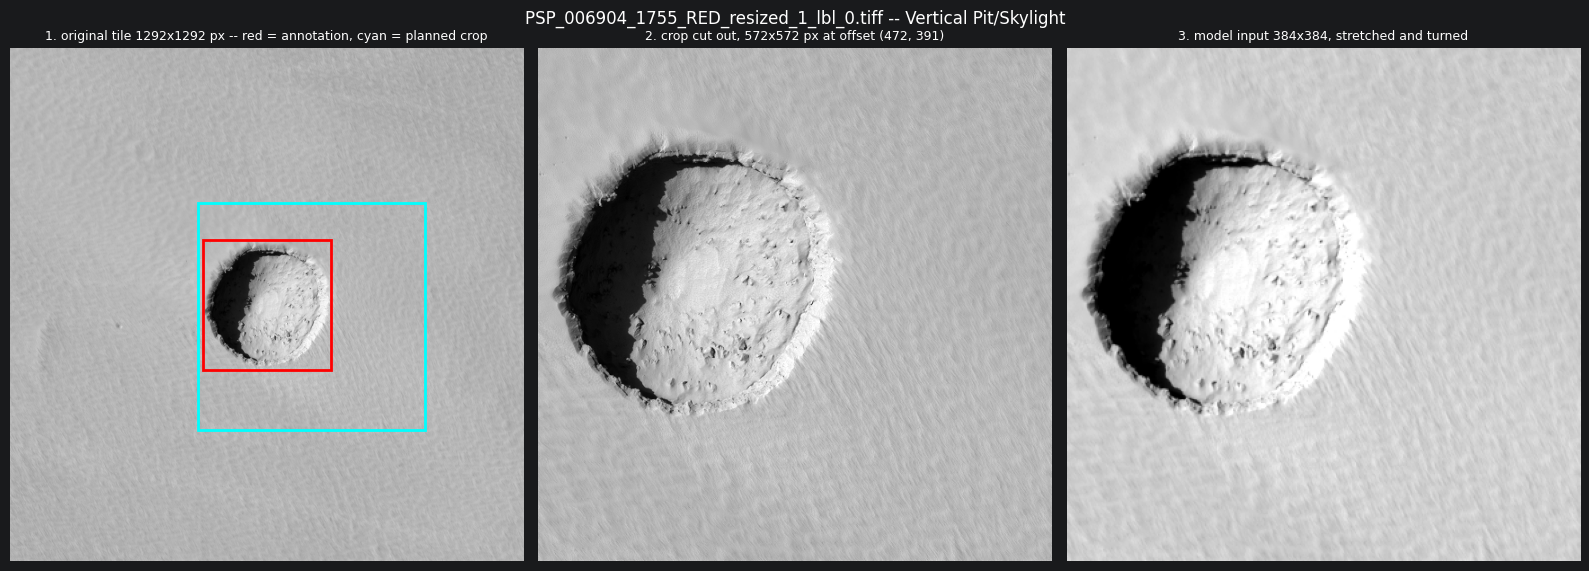

tile side / landform side = 4.0
crop covers 20% of the tile area


In [6]:
import matplotlib.patches as patches
import rasterio
from data.optical.landform_crops import plan_crop, read_crop
from model.landform_dataset import LandformDataset

EXAMPLE = "PSP_006904_1755_RED_resized_1_lbl_0.tiff"
example = sizes[sizes.file_name == EXAMPLE].iloc[0]
example_path = os.path.join(TILE_DIR, EXAMPLE)

rng = np.random.default_rng(7)
plan = plan_crop(example["width"], example["height"], example["bbox"], 1.75, rng)

with rasterio.open(example_path) as src:
    whole_tile = src.read(1)

native = read_crop(example_path, plan)
model_input = LandformDataset.stretch_intensity(
    read_crop(example_path, plan, out_px=384)
)
model_input = LandformDataset.random_dihedral(model_input, rng)

bx, by, bw, bh = example["bbox"]

fig, axs = plt.subplots(1, 3, figsize=(16, 5.8))

axs[0].imshow(whole_tile, cmap="gray")
axs[0].add_patch(patches.Rectangle((bx, by), bw, bh, lw=2,
                                   edgecolor="red", facecolor="none"))
axs[0].add_patch(patches.Rectangle((plan.col_off, plan.row_off), plan.side,
                                   plan.side, lw=2, edgecolor="cyan",
                                   facecolor="none"))
axs[0].set_title(
    "1. original tile {}x{} px -- red = annotation, cyan = planned crop".format(
        example["width"], example["height"]), fontsize=9)

axs[1].imshow(native, cmap="gray")
axs[1].set_title(
    "2. crop cut out, {0}x{0} px at offset ({1}, {2})".format(
        plan.side, plan.col_off, plan.row_off), fontsize=9)

axs[2].imshow(model_input, cmap="gray")
axs[2].set_title("3. model input 384x384, stretched and turned", fontsize=9)

for ax in axs:
    ax.axis("off")
fig.suptitle("{} -- {}".format(EXAMPLE, CLASS_NAMES[example["category_id"]]))
plt.tight_layout()
plt.show()

longest = max(example["bbox"][2], example["bbox"][3])
print("tile side / landform side = {:.1f}".format(example["width"] / longest))
print("crop covers {:.0f}% of the tile area".format(
    100 * plan.side ** 2 / (example["width"] * example["height"])))

### What a crop looks like

Four independent draws of the same annotation. The landform stays whole and
inside the frame; where it sits, and its orientation, change every time.

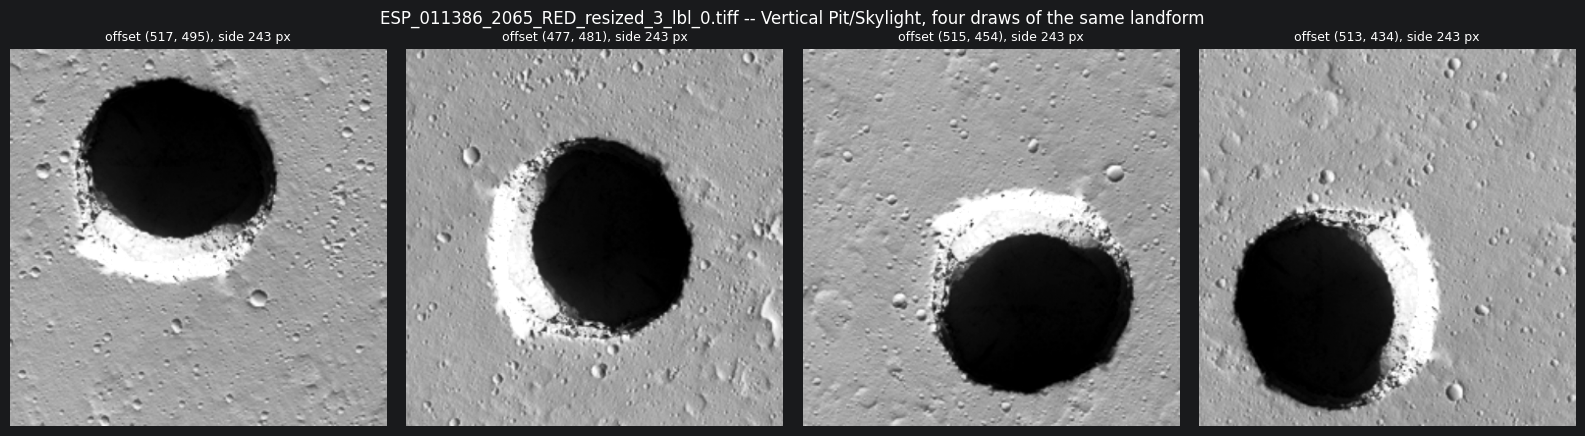

In [7]:
row = sizes[sizes.category_id == 0].iloc[3]
tile_path = os.path.join(TILE_DIR, row["file_name"])

fig, axs = plt.subplots(1, 4, figsize=(16, 4.4))
for ax, seed in zip(axs, range(4)):
    rng = np.random.default_rng(seed)
    plan = plan_crop(row["width"], row["height"], row["bbox"], 1.75, rng)
    patch = LandformDataset.stretch_intensity(read_crop(tile_path, plan, out_px=384))
    patch = LandformDataset.random_dihedral(patch, rng)
    ax.imshow(patch, cmap="gray")
    ax.set_title(f"offset ({plan.col_off}, {plan.row_off}), side {plan.side} px",
                 fontsize=9)
    ax.axis("off")

fig.suptitle(f"{row['file_name']} -- {CLASS_NAMES[row['category_id']]}, "
             "four draws of the same landform")
plt.tight_layout()
plt.show()

## 4. Annotation table

One row per annotation, carrying everything the dataset and the split need.
Building it reads every tile's georeferencing, which takes about a minute, so
the result is cached to `data/optical/final_data/annotations.json`. Set
`REBUILD = True` to force a rebuild.

`lat` / `lon_east` are the centre of the **annotation**, not of the tile or of
the crop. The thermal pipeline keys its windows on that: a THEMIS pixel is
~100 m and the median annotated landform is 396 m across -- 155 m for Type-1 --
so a window centred on anything else misses the target.

In [8]:
from data.optical.landform_crops import annotation_table

REBUILD = not os.path.exists(ANNOTATIONS)

if REBUILD:
    annotations = annotation_table(DATASET_JSON, TILE_DIR, with_coordinates=True)
    annotations.to_json(ANNOTATIONS)
    print(f"\nwritten to {ANNOTATIONS}")
else:
    annotations = pd.read_json(ANNOTATIONS)
    print(f"loaded {len(annotations)} rows from {ANNOTATIONS}")

annotations.head()

loaded 1846 rows from data\optical\final_data\annotations.json


,image_name,img_path,category_id,category_name,bbox,landform_key,product,resolution_mpp,tile_width,tile_height,box_px,diameter_m,lat,lon_east
0,ESP_011386_2065_RED_resized_0.5_lbl_0.tiff,data/optical/DeepLandforms_dataset,0,Type-1,"[438, 449, 830, 799]",ESP_011386_2065_RED_lbl_0,ESP_011386_2065,0.5,1729,1728,830,415.0,26.148813,259.342976
1,ESP_011386_2065_RED_resized_0.5_lbl_1.tiff,data/optical/DeepLandforms_dataset,1,Type-4,"[523, 535, 1048, 1016]",ESP_011386_2065_RED_lbl_1,ESP_011386_2065,0.5,2116,2116,1048,524.0,26.124252,259.347467
2,ESP_011386_2065_RED_resized_1_lbl_0.tiff,data/optical/DeepLandforms_dataset,0,Type-1,"[399, 407, 415, 399]",ESP_011386_2065_RED_lbl_0,ESP_011386_2065,1.0,1212,1212,415,415.0,26.148813,259.342971
3,ESP_011386_2065_RED_resized_1_lbl_1.tiff,data/optical/DeepLandforms_dataset,1,Type-4,"[508, 516, 524, 508]",ESP_011386_2065_RED_lbl_1,ESP_011386_2065,1.0,1540,1540,524,524.0,26.124248,259.347472
4,ESP_011386_2065_RED_resized_2_lbl_0.tiff,data/optical/DeepLandforms_dataset,0,Type-1,"[400, 404, 208, 200]",ESP_011386_2065_RED_lbl_0,ESP_011386_2065,2.0,1008,1008,208,416.0,26.148813,259.342979


## 5. Splitting

`LandformDataset.group_keys`. Three separate things put correlated samples in
this data set, and a split that ignores any of them reports a score that is too
high:

1. **Resolution replicas** -- the same landform at 0.5/1/2/3/5 m/pixel. A random
   row split puts rescaled copies of one pit on both sides (measured on the
   earlier data set: 73.8% of validation images had a copy in training). Caught
   by stripping the resolution token from the filename.
2. **Repeat observations** -- the same pit imaged on several orbits under
   different product ids, so filenames give no hint they are the same feature.
   Caught by proximity on the ground, 300 m.
3. **Shared acquisition** -- two *different* landforms in one HiRISE product
   share season, solar incidence angle, calibration and local terrain. Caught by
   grouping on the product id.

Relations are combined by union-find, so a group is a connected component rather
than an intersection. Two levels are offered:

* `level="landform"` -- relations 1 and 2. Answers *can the model recognise a pit
  it has never seen?*
* `level="product"` -- all three. Answers *can it do that in an image it has
  never seen?* **This is the number to report.** The gap between the two
  measures how much the model leans on acquisition context.


In [9]:
dataset = LandformDataset(annotations, root_dir=".")

summary = []
for level in ("landform", "product"):
    groups = pd.Series(dataset.group_keys(level=level))
    per_class = pd.crosstab(groups, annotations["category_id"])
    summary.append({
        "level": level,
        "groups": groups.nunique(),
        "images": len(groups),
        "median group size": int(groups.value_counts().median()),
        "largest group, % of data": round(
            100 * groups.value_counts().iloc[0] / len(groups), 1),
        **{f"groups with {CLASS_NAMES[c]}": int((per_class[c] > 0).sum())
           for c in per_class.columns},
    })

print(pd.DataFrame(summary).set_index("level").T.to_string())
print("\n1846 images is NOT the sample size. 318 landform groups and 127")
print("product groups are.")

level                              landform  product
groups                                318.0    127.0
images                               1846.0   1846.0
median group size                       5.0     10.0
largest group, % of data                1.1      8.2
groups with Vertical Pit/Skylight      93.0     81.0
groups with Aligned Shallow Pit       111.0     37.0
groups with Sloped Pit                123.0     56.0

1846 images is NOT the sample size. 318 landform groups and 127
product groups are.


In [10]:
from model.training_utils import group_kfold_indices

# The folds have to hold: no group may appear on both sides of a split.
for level in ("landform", "product"):
    groups = np.array(dataset.group_keys(level=level))
    folds = group_kfold_indices(groups, dataset.img_labels, n_splits=5, seed=42)
    for fold, (train_idx, val_idx) in enumerate(folds, start=1):
        overlap = set(groups[train_idx]) & set(groups[val_idx])
        assert not overlap, f"{level} fold {fold} leaks {len(overlap)} groups"
    print(f"{level:9s}: 5 folds, validation sizes "
          f"{[len(v) for _, v in folds]}, no group straddles a fold")

landform : 5 folds, validation sizes [370, 367, 370, 368, 371], no group straddles a fold
product  : 5 folds, validation sizes [367, 366, 368, 378, 367], no group straddles a fold


## 6. What the data set contains

Summary, including the parts that constrain what can be claimed.

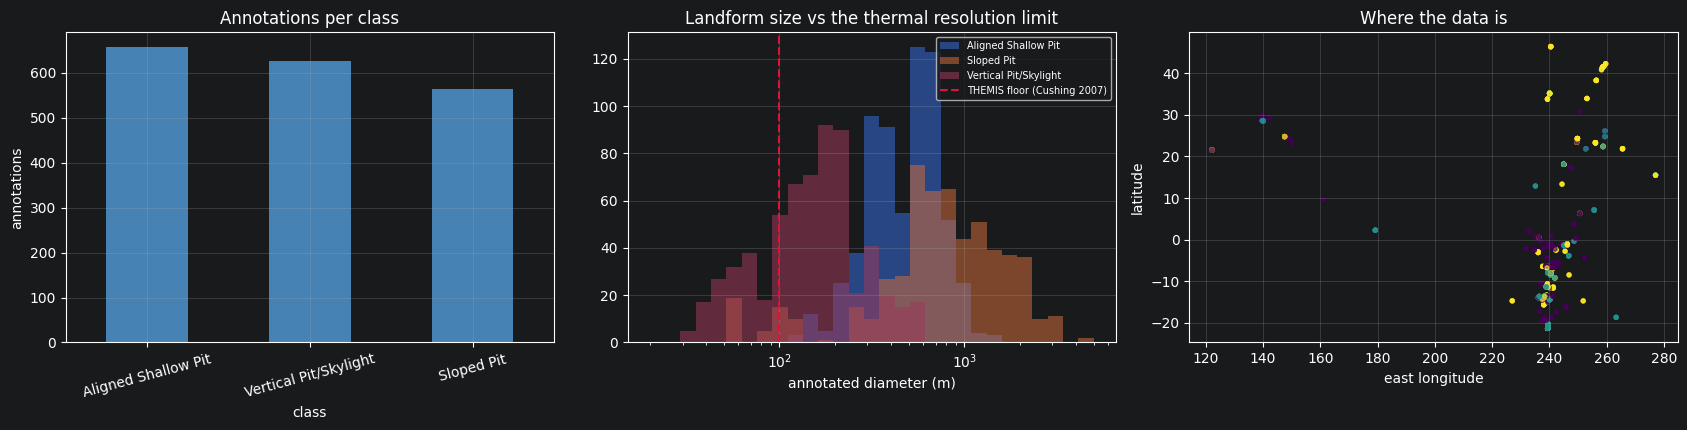

Geographic concentration (10 deg cells):
lon_bin  lat_bin
240      -10        356
230      -20        292
240      -20        207
230      -10        207
         -30        135

top 5 cells hold 65% of all annotations -- Tharsis (Arsia/Pavonis) and Cerberus/Elysium.

Landform size against the 100 m THEMIS floor:
  median diameter, all classes : 396 m (4.0 THEMIS px)
  median diameter, Type-1 only : 155 m (1.6 THEMIS px)
  below 100 m                  : 10% of all, 24% of Type-1


In [11]:
annotations["class"] = annotations["category_id"].map(CLASS_NAMES)

fig, axs = plt.subplots(1, 3, figsize=(17, 4.4))

annotations["class"].value_counts().plot.bar(ax=axs[0], rot=15, color="steelblue")
axs[0].set_title("Annotations per class")
axs[0].set_ylabel("annotations")

for name, group in annotations.groupby("class"):
    axs[1].hist(group["diameter_m"], bins=np.logspace(1.3, 3.7, 30),
                alpha=0.55, label=name)
axs[1].axvline(100, ls="--", c="crimson", lw=1.5,
               label="THEMIS floor (Cushing 2007)")
axs[1].set_xscale("log")
axs[1].set_xlabel("annotated diameter (m)")
axs[1].set_title("Landform size vs the thermal resolution limit")
axs[1].legend(fontsize=7)

scatter = axs[2].scatter(annotations["lon_east"], annotations["lat"],
                         c=annotations["category_id"], cmap="viridis",
                         s=8, alpha=0.6)
axs[2].set_xlabel("east longitude")
axs[2].set_ylabel("latitude")
axs[2].set_title("Where the data is")
for ax in axs:
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

region = annotations.assign(
    lon_bin=(annotations.lon_east // 10 * 10).astype(int),
    lat_bin=(annotations.lat // 10 * 10).astype(int),
)
top = region.groupby(["lon_bin", "lat_bin"]).size().sort_values(ascending=False)
print("Geographic concentration (10 deg cells):")
print(top.head(5).to_string())
print(f"\ntop 5 cells hold {top.head(5).sum() / len(annotations) * 100:.0f}% of "
      "all annotations -- Tharsis (Arsia/Pavonis) and Cerberus/Elysium.")

print("\nLandform size against the 100 m THEMIS floor:")
print(f"  median diameter, all classes : {annotations.diameter_m.median():.0f} m "
      f"({annotations.diameter_m.median() / 100:.1f} THEMIS px)")
skylights = annotations[annotations.category_id == 0]
print(f"  median diameter, Type-1 only : {skylights.diameter_m.median():.0f} m "
      f"({skylights.diameter_m.median() / 100:.1f} THEMIS px)")
print(f"  below 100 m                  : "
      f"{(annotations.diameter_m < 100).mean() * 100:.0f}% of all, "
      f"{(skylights.diameter_m < 100).mean() * 100:.0f}% of Type-1")


### Limitations to carry into the paper

1. **Sample size is 318 landform groups / 127 product groups**, not 1846 images.
   Report group-level `n`, use `StratifiedGroupKFold`, quote fold-to-fold spread.
   At product level Type-4 appears in only 37 groups.
2. **Geography.** Two volcanic provinces, one planet. That is where Martian pits
   are, so it is defensible, but it does not support a claim of "diverse
   planetary terrains". A region hold-out -- train Tharsis, test Elysium -- would
   be a stronger result than a random split and costs nothing.
3. **Solar incidence angle is the next confound to check.** What separates these
   classes optically is shadow depth and whether a floor is visible, and that is
   a function of illumination; Nodjoumi says as much. `stretch_intensity` removes
   the brightness offset but not the shadow geometry. Pull incidence angle per
   product and run the statistics-only baseline against it. If incidence alone
   predicts the class, that is a finding, not a nuisance.
4. **Label noise.** Classes were assigned by qualitative morphological inspection
   without topographic profiles, by the DeepLandforms authors' own description.
   Type-1b / Type-2a / Type-4 confusion is expected and bounds achievable
   accuracy.
5. **Georeferencing.** Nodjoumi reports uncontrolled misalignment between MGC^3
   points and the HiRISE products, and advises co-registration to a common
   basemap. That bounds how precisely thermal windows can be placed, whatever
   the code does.
6. **The skylight class sits at the thermal resolution limit.** Median annotated
   diameter is 396 m, i.e. 4.0 THEMIS pixels -- but for Type-1, the class that
   matters, it is 155 m, i.e. 1.6 pixels, and 24% of Type-1 annotations fall
   below Cushing's stated ~100 m detectability floor outright.

## 7. Thermal coverage is not random

The thermal pipeline (`data/thermal/`) queries one window per **landform site**
-- the same grouping the training split uses, so a site and a CV group are the
same object. Not every site gets one: THEMIS revisits depend on orbit geometry,
so some landforms have three usable frames, some have one, some none.

That missingness is a limitation to report rather than a bug to fix, but it has
to be *measured*, because **it is not independent of the class.** THEMIS
coverage depends on where a site is, and where a site is correlates with what it
is. If a model is handed zero-padded thermal for missing sites, it can read the
padding pattern and gain accuracy with no thermal physics involved at all --
which would look exactly like "multimodal fusion helps".

The cell below quantifies it: a classifier given the coverage bookkeeping and
**not one Kelvin value** is asked to predict the class. Whatever it scores above
the majority class is the size of the trap:

| task | availability only | majority | lift |
|---|---|---|---|
| 3-class | 41.7% | 35.6% | **+6.1** |
| binary Type-1 vs rest | 64.8% | 66.1% | **-1.3** |

**On the headline binary task the leak is gone** -- coverage predicts the class
no better than guessing the majority. On 3-class it survives, and the
decomposition below shows why: no single coverage feature carries more than
about +1.5, but all of them together carry +6.1. Coverage is not describing the
landform, it is fingerprinting *where on Mars* the landform is, and that
correlates with class.

Two consequences, both already in place in the code:

* The thermal branch takes an explicit **availability mask channel** rather than
  bare zeros. It does not remove the leak -- the model can still read the mask --
  but it turns it into a named input that can be ablated and measured, and it
  separately fixes a real problem, since THEMIS writes 0 for no-data and a cold
  pixel would otherwise be indistinguishable from a missing one.
* `model/baselines.availability_features` keeps this as a permanent control. If
  a multimodal model beats optical-only by no more than this baseline beats the
  majority class, the gain is coverage bookkeeping, not physics.

In [12]:
from model.baselines import availability_features, evaluate_baseline

ANNOTATION_SITES = os.path.join(DATA, "thermal", "annotation_sites.csv")
MANIFEST = os.path.join(DATA, "thermal", "themis_data", "window_manifest.json")

availability = None
if os.path.exists(ANNOTATION_SITES):
    annotation_sites = pd.read_csv(ANNOTATION_SITES)
    availability = availability_features(annotation_sites, MANIFEST)

if availability is None:
    print("No thermal manifest matching the current landform sites.")
    print("Run data/thermal/thermal_data_collection.ipynb, then re-run this cell.")
    print()
    print("The numbers in the markdown above are from the superseded grid-based")
    print("run and stand as the order of magnitude to expect.")
else:
    coverage = annotations[["category_id"]].copy()
    coverage["class"] = coverage["category_id"].map(CLASS_NAMES)
    coverage["n_frames"] = availability["n_frames"].to_numpy()

    print("Frames per site, as a share of each class:")
    print(pd.crosstab(coverage["class"], coverage["n_frames"],
                      normalize="index").round(3).to_string())
    print()
    print("Mean frames per class:")
    print(coverage.groupby("class")["n_frames"].mean().round(2).to_string())

    from scipy.stats import kruskal

    per_class = [coverage.loc[coverage.category_id == c, "n_frames"]
                 for c in sorted(coverage.category_id.unique())]
    statistic, pvalue = kruskal(*per_class)
    print()
    print(f"Kruskal-Wallis across classes: H = {statistic:.1f}, p = {pvalue:.2g}")

Frames per site, as a share of each class:
n_frames                   0      1      2      3
class                                            
Aligned Shallow Pit    0.008  0.000  0.000  0.992
Sloped Pit             0.027  0.000  0.041  0.933
Vertical Pit/Skylight  0.000  0.032  0.040  0.928

Mean frames per class:
class
Aligned Shallow Pit      2.98
Sloped Pit               2.88
Vertical Pit/Skylight    2.90

Kruskal-Wallis across classes: H = 35.6, p = 1.8e-08


Class information carried by thermal coverage alone (%):


,availability only,majority,lift
task,,,
3-class,41.7,35.6,6.1
binary Type-1 vs rest,64.8,66.1,-1.3


The 'lift' column is how much a multimodal model must beat
optical-only by before the gain can be attributed to thermal physics.


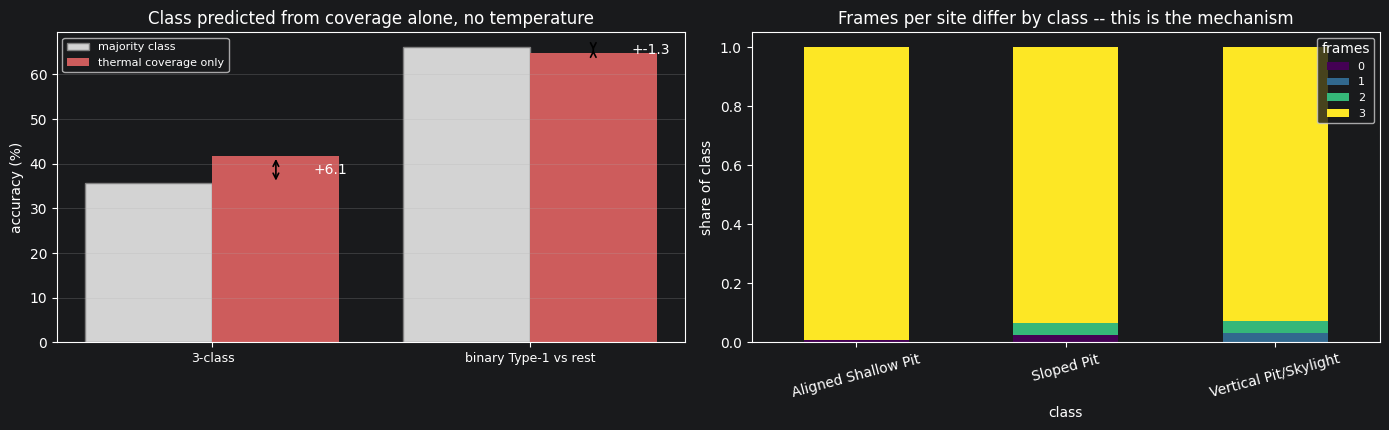

In [13]:
if availability is not None:
    # The control itself, scored exactly like every other baseline: same
    # group-aware folds, same estimator, no temperature anywhere in the input.
    groups = dataset.group_keys(level="product")

    rows = []
    for task_name, task_targets in (
        ("3-class", annotations["category_id"].to_numpy()),
        ("binary Type-1 vs rest",
         (annotations["category_id"] == 0).astype(int).to_numpy()),
    ):
        scored = evaluate_baseline(availability, task_targets, groups)
        floor = pd.Series(task_targets).value_counts(normalize=True).max()
        rows.append({
            "task": task_name,
            "availability only": scored["acc"].mean() * 100,
            "majority": floor * 100,
            "lift": (scored["acc"].mean() - floor) * 100,
        })

    leak = pd.DataFrame(rows).set_index("task").round(1)
    print("Class information carried by thermal coverage alone (%):")
    display(leak)
    print("The 'lift' column is how much a multimodal model must beat")
    print("optical-only by before the gain can be attributed to thermal physics.")

    fig, axs = plt.subplots(1, 2, figsize=(14, 4.4))

    positions = np.arange(len(leak))
    axs[0].bar(positions - 0.2, leak["majority"], 0.4,
               label="majority class", color="lightgrey", edgecolor="grey")
    axs[0].bar(positions + 0.2, leak["availability only"], 0.4,
               label="thermal coverage only", color="indianred")
    for x, (floor, scored) in enumerate(
        zip(leak["majority"], leak["availability only"])
    ):
        axs[0].annotate("", xy=(x + 0.2, scored), xytext=(x + 0.2, floor),
                        arrowprops=dict(arrowstyle="<->", color="black", lw=1.2))
        axs[0].text(x + 0.32, (scored + floor) / 2,
                    "+{:.1f}".format(scored - floor), va="center", fontsize=10)
    axs[0].set_xticks(positions)
    axs[0].set_xticklabels(leak.index, fontsize=9)
    axs[0].set_ylabel("accuracy (%)")
    axs[0].set_title("Class predicted from coverage alone, no temperature")
    axs[0].legend(fontsize=8)
    axs[0].grid(alpha=0.3, axis="y")

    shares = pd.crosstab(coverage["class"], coverage["n_frames"], normalize="index")
    shares.plot.bar(stacked=True, ax=axs[1], rot=15, colormap="viridis")
    axs[1].set_title("Frames per site differ by class -- this is the mechanism")
    axs[1].set_ylabel("share of class")
    axs[1].legend(title="frames", fontsize=8)

    plt.tight_layout()
    plt.show()

In [14]:
if availability is not None:
    # Which part of the coverage pattern carries the class? Each subset alone
    # against all of them together -- the gap between the two is the tell.
    subsets = {
        "frame count only": ["n_frames"],
        "counts": ["n_frames", "n_usable", "has_thermal"],
        "local solar time": ["lmst_min", "lmst_max", "lmst_span"],
        "pixel validity": ["valid_mean", "valid_min"],
        "all of them": list(availability.columns),
    }

    rows = []
    for task_name, task_targets in (
        ("3-class", annotations["category_id"].to_numpy()),
        ("binary Type-1 vs rest",
         (annotations["category_id"] == 0).astype(int).to_numpy()),
    ):
        floor = pd.Series(task_targets).value_counts(normalize=True).max() * 100
        for subset_name, columns in subsets.items():
            scored = evaluate_baseline(availability[columns], task_targets, groups)
            rows.append({
                "task": task_name,
                "features": subset_name,
                "accuracy": scored["acc"].mean() * 100,
                "lift over majority": scored["acc"].mean() * 100 - floor,
            })

    decomposition = (pd.DataFrame(rows)
                     .pivot(index="features", columns="task",
                            values="lift over majority")
                     .reindex(list(subsets))
                     .round(1))
    print("Lift over the majority class, by feature subset:")
    display(decomposition)
    print("No single subset carries much. Their combination carries more, which")
    print("is what a location fingerprint looks like: coverage is a proxy for")
    print("where the site is, and where correlates with what.")

Lift over the majority class, by feature subset:


task,3-class,binary Type-1 vs rest
features,,
frame count only,1.6,-0.7
counts,1.3,-1.8
local solar time,1.4,-4.6
pixel validity,1.7,-1.9
all of them,6.1,-1.3


No single subset carries much. Their combination carries more, which
is what a location fingerprint looks like: coverage is a proxy for
where the site is, and where correlates with what.


## 9. What the thermal branch actually sees

Sections 6 and 7 give the numbers -- median Type-1 diameter 155 m against a
100 m THEMIS pixel, 3.2% of observations in the pre-dawn window. This section
draws them, because the numbers understate how little is there.

`ThermalEncoder` does not average the window. It pools over a **centre disc**
(radius 2 px, 200 m) covering the landform and an **annulus** (5-9 px, 500-900 m)
of undisturbed ground beside it, and passes on both plus their difference,
because Cushing et al. (2007) identify a cave-connected pit by its temperature
*relative to the ground next to it*, not by its temperature.

Three things decide whether that difference can carry anything, and each fails
for a different part of the data set:

1. **Size.** The disc is 2 px across in radius; the median Type-1 is 1.6 px in
   diameter. Below about 1 px the disc is averaging mostly surroundings, so an
   anomaly is diluted before it is measured.
2. **Time.** The contrast changes *sign* with local solar time -- see
   `data.thermal.collect.frame_times`. Pre-dawn is Cushing's regime; the
   afternoon signal is shadow, which is morphology the optical branch already
   reads.
3. **Geometry.** For a landform larger than about 10 px the annulus lies
   *inside the pit*, so the "reference ground" is not reference ground and the
   difference is measuring the pit against itself. 55% of Type-2 sites are in
   that regime.

The figure below picks one site for each failure mode and one that works.
Colour is fixed at +/-6 K about each frame's own median so amplitudes are
comparable between panels; grey is no data.

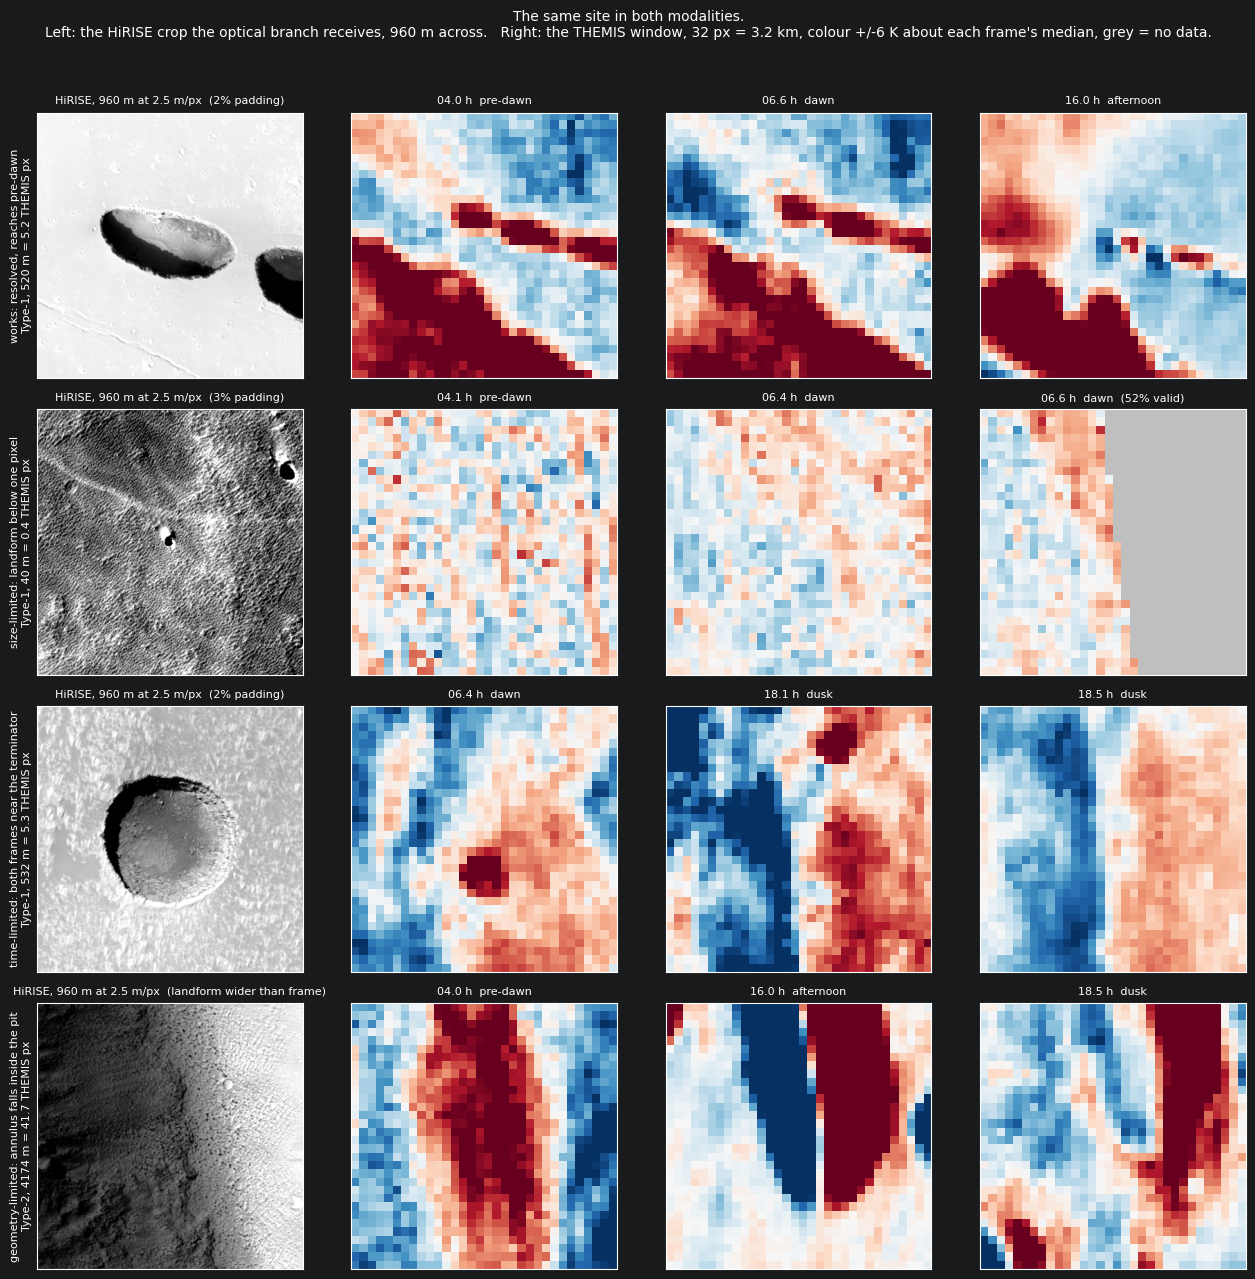

works: resolved, reaches pre-dawn            lf_0226  Type-1     520 m  LMST [4.0, 6.6, 16.0]
size-limited: landform below one pixel       lf_0152  Type-1      40 m  LMST [4.1, 6.4, 6.6]
time-limited: both frames near the terminator lf_0027  Type-1     532 m  LMST [6.4, 18.1, 18.5]
geometry-limited: annulus falls inside the pit lf_0118  Type-2    4174 m  LMST [4.0, 16.0, 18.5]


In [18]:
import json
from data.optical.landform_crops import plan_crop_fixed, read_crop
from model.landform_dataset import LandformDataset
from data.thermal.themis_windows import NODATA_KELVIN

MANIFEST_PATH = os.path.join(DATA, "thermal", "themis_data", "window_manifest.json")
WINDOWS_DIR = os.path.join(DATA, "thermal", "themis_data", "windows")

#: THEMIS ground sampling distance, metres per pixel.
THEMIS_MPP = 100.0
#: Pooling geometry of model.model.ThermalEncoder, in THEMIS pixels.
CENTRE_RADIUS, ANNULUS_INNER, ANNULUS_OUTER = 2.0, 5.0, 9.0
#: Fixed colour range, so amplitude is comparable between panels.
SCALE_K = 6.0

SHORT = {0: "Type-1", 1: "Type-4", 2: "Type-2"}


def thermal_site_table():
    """One row per site with a stored window: class, size, and what it samples."""
    with open(MANIFEST_PATH) as handle:
        manifest = {entry["site_id"]: entry for entry in json.load(handle)}

    joined = annotations.assign(site_id=annotation_sites["site_id"].to_numpy())
    rows = []
    for site_id, group in joined.groupby("site_id"):
        entry = manifest.get(site_id)
        if entry is None or not os.path.exists(
            os.path.join(WINDOWS_DIR, f"{site_id}.npy")
        ):
            continue
        hours = [f["mars_lmst_decimal_hours"] for f in entry["frames"]
                 if f["mars_lmst_decimal_hours"] is not None]
        diameter = float(group["diameter_m"].median())
        # Replica to draw in the optical panel. Tiles are a roughly constant
        # number of pixels, so their ground extent scales with resolution:
        # picking the finest replica picks the *smallest* patch of Mars and
        # fills the panel with padding. Prefer one that covers the window, and
        # among those take the finest; otherwise take the widest available.
        extent_m = group["tile_width"] * group["resolution_mpp"]
        covering = group[extent_m >= 960.0]
        finest = (covering["resolution_mpp"].idxmin() if len(covering)
                  else extent_m.idxmax())
        rows.append({
            "site_id": site_id,
            "annotation_row": finest,
            "category_id": int(group["category_id"].iloc[0]),
            "diameter_m": diameter,
            "themis_px": diameter / THEMIS_MPP,
            "n_frames": len(hours),
            "hours": hours,
            "has_predawn": any(2 <= h < 6 for h in hours),
        })
    return pd.DataFrame(rows)


def local_time_band(hour):
    if 2 <= hour < 6:
        return "pre-dawn"
    if 6 <= hour < 10:
        return "dawn"
    if 14 <= hour < 18:
        return "afternoon"
    if 18 <= hour < 22:
        return "dusk"
    return ""


#: Ground extent and scale of the optical panel. Deliberately the training
#: footprint and the training GSD, so the panel is literally what the optical
#: branch receives -- not a prettier rendering made for the figure.
OPTICAL_FOOTPRINT_M, OPTICAL_PX = 960.0, 384


def draw_optical(ax, annotation_row, diameter_m):
    """The HiRISE crop the network is given, at the same site.

    Nothing is drawn over the imagery: the panels are meant to show what the
    two instruments record, not where the model chooses to look.
    """
    row = annotations.loc[annotation_row]
    plan = plan_crop_fixed(row["tile_width"], row["tile_height"], row["bbox"],
                           resolution_mpp=row["resolution_mpp"],
                           footprint_m=OPTICAL_FOOTPRINT_M, rng=None)
    patch = LandformDataset.stretch_intensity(
        read_crop(os.path.join(row["img_path"], row["image_name"]), plan,
                  out_px=OPTICAL_PX)
    )
    ax.imshow(patch, cmap="gray")

    ax.set_xlim(-0.5, OPTICAL_PX - 0.5)
    ax.set_ylim(OPTICAL_PX - 0.5, -0.5)
    ax.set_xticks([])
    ax.set_yticks([])

    # Two things the reader would otherwise have to guess: a landform wider than
    # the window has no visible circle, and black is padding rather than terrain.
    note = ""
    if diameter_m > OPTICAL_FOOTPRINT_M:
        note = "  (landform wider than frame)"
    elif (patch == 0).mean() > 0.02:
        note = f"  ({100 * (patch == 0).mean():.0f}% padding)"
    ax.set_title(f"HiRISE, {OPTICAL_FOOTPRINT_M:.0f} m at "
                 f"{OPTICAL_FOOTPRINT_M / OPTICAL_PX:.1f} m/px{note}", fontsize=8)


def draw_window(ax, frame, hour):
    """One THEMIS frame with the encoder's pooling geometry drawn on it."""
    valid = frame != NODATA_KELVIN
    shown = np.where(valid, frame, np.nan)
    if valid.any():
        # Same per-window median subtraction the dataset applies, so the panel
        # shows what the network is given rather than absolute Kelvin.
        shown = shown - np.median(frame[valid])

    cmap = plt.get_cmap("RdBu_r").copy()
    cmap.set_bad("0.75")   # no data, so it is never read as a cold pixel
    ax.imshow(shown, cmap=cmap, vmin=-SCALE_K, vmax=SCALE_K)

    ax.set_xlim(-0.5, frame.shape[1] - 0.5)
    ax.set_ylim(frame.shape[0] - 0.5, -0.5)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"{hour:04.1f} h  {local_time_band(hour)}"
                 + ("" if valid.all() else f"  ({100 * valid.mean():.0f}% valid)"),
                 fontsize=8)


thermal_sites = thermal_site_table()


def pick(mask, smallest=False):
    subset = thermal_sites[mask & (thermal_sites.n_frames >= 3)]
    return None if subset.empty else subset.sort_values(
        "themis_px", ascending=smallest).iloc[0]


cases = [
    ("works: resolved, reaches pre-dawn",
     pick((thermal_sites.category_id == 0) & thermal_sites.has_predawn
          & (thermal_sites.themis_px > 2))),
    ("size-limited: landform below one pixel",
     pick((thermal_sites.category_id == 0) & thermal_sites.has_predawn
          & (thermal_sites.themis_px < 1), smallest=True)),
    ("time-limited: both frames near the terminator",
     pick((thermal_sites.category_id == 0) & ~thermal_sites.has_predawn
          & (thermal_sites.themis_px > 2))),
    ("geometry-limited: annulus falls inside the pit",
     pick((thermal_sites.category_id == 2) & (thermal_sites.themis_px > 20))),
]
cases = [(label, row) for label, row in cases if row is not None]

fig, axs = plt.subplots(len(cases), 4, figsize=(13, 3.25 * len(cases)))
for r, (label, row) in enumerate(cases):
    stack = np.load(os.path.join(WINDOWS_DIR, f"{row.site_id}.npy")).astype(np.float32)
    draw_optical(axs[r, 0], row.annotation_row, row.diameter_m)
    for c in range(3):
        if c < len(stack):
            draw_window(axs[r, c + 1], stack[c], row.hours[c])
        else:
            axs[r, c + 1].axis("off")
    axs[r, 0].set_ylabel(
        f"{label}\n{SHORT[row.category_id]}, {row.diameter_m:.0f} m "
        f"= {row.themis_px:.1f} THEMIS px", fontsize=8)
    axs[r, 0].set_yticks([])

fig.suptitle(
    "The same site in both modalities." "\n"
    "Left: the HiRISE crop the optical branch receives, 960 m across.   "
    f"Right: the THEMIS window, 32 px = 3.2 km, colour +/-{SCALE_K:.0f} K "
    "about each frame's median, grey = no data.", fontsize=10)
plt.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

for label, row in cases:
    print(f"{label:44s} {row.site_id}  {SHORT[row.category_id]:7s} "
          f"{row.diameter_m:6.0f} m  LMST {[round(h, 1) for h in row.hours]}")

### How much of the data set is in each regime

The figure is four sites. This is all 314.

Sites by landform size and whether the sequence reaches 02-06 h:
col_0      no pre-dawn frame  reaches pre-dawn  All
themis_px                                          
<1 px                     25                 8   33
1-2 px                    35                11   46
2-4 px                    49                14   63
4-10 px                   88                26  114
>10 px                    42                16   58
All                      239                75  314

Resolved (2-10 px), annulus still outside the pit, AND a pre-dawn frame:
  40 of 314 sites (13%)
Type-4    17
Type-2    14
Type-1     9


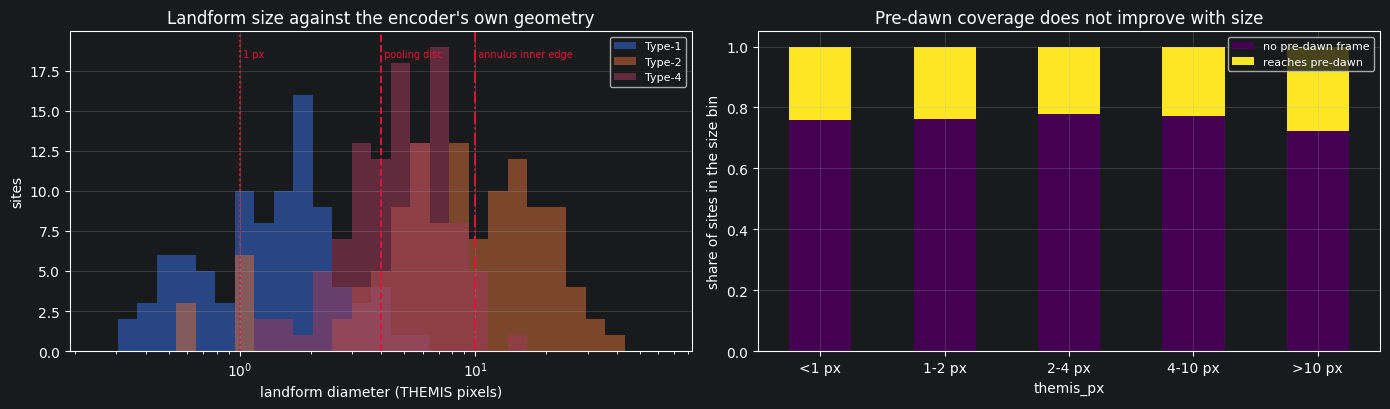

In [16]:
size_bin = pd.cut(thermal_sites.themis_px, [0, 1, 2, 4, 10, 1e9],
                  labels=["<1 px", "1-2 px", "2-4 px", "4-10 px", ">10 px"])
time_bin = np.where(thermal_sites.has_predawn,
                    "reaches pre-dawn", "no pre-dawn frame")

print("Sites by landform size and whether the sequence reaches 02-06 h:")
print(pd.crosstab(size_bin, time_bin, margins=True).to_string())

usable = thermal_sites[(thermal_sites.themis_px >= 2)
                       & (thermal_sites.themis_px <= 10)
                       & thermal_sites.has_predawn]
print()
print(f"Resolved (2-10 px), annulus still outside the pit, AND a pre-dawn frame:")
print(f"  {len(usable)} of {len(thermal_sites)} sites "
      f"({100 * len(usable) / len(thermal_sites):.0f}%)")
print(pd.Series([SHORT[c] for c in usable.category_id])
      .value_counts().to_string())

fig, axs = plt.subplots(1, 2, figsize=(14, 4.2))

for name, group in thermal_sites.groupby(thermal_sites.category_id.map(SHORT)):
    axs[0].hist(group.themis_px, bins=np.logspace(-0.6, 1.8, 30),
                alpha=0.55, label=name)
for radius, style, note in [(1, ":", "1 px"),
                            (CENTRE_RADIUS * 2, "--", "pooling disc"),
                            (ANNULUS_INNER * 2, "-.", "annulus inner edge")]:
    axs[0].axvline(radius, ls=style, c="crimson", lw=1.4)
    axs[0].text(radius, axs[0].get_ylim()[1] * 0.92, f" {note}",
                fontsize=7, color="crimson")
axs[0].set_xscale("log")
axs[0].set_xlabel("landform diameter (THEMIS pixels)")
axs[0].set_ylabel("sites")
axs[0].set_title("Landform size against the encoder's own geometry")
axs[0].legend(fontsize=8)

shares = pd.crosstab(size_bin, time_bin, normalize="index")
shares.plot.bar(stacked=True, ax=axs[1], rot=0, colormap="viridis")
axs[1].set_title("Pre-dawn coverage does not improve with size")
axs[1].set_ylabel("share of sites in the size bin")
axs[1].legend(fontsize=8)

for ax in axs:
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### What this means for the paper

Putting the three constraints together -- resolved but not so large that the
annulus falls inside the pit, and a sequence that reaches pre-dawn -- **40 of 314
sites qualify, 13%**. Of those, **nine are Type-1**, the class the paper is
about. Nine independent sites is not a data set; it is an anecdote.

Note the right-hand panel: pre-dawn coverage is flat at about 24% across every
size bin. The two constraints are independent, so they multiply rather than
overlap, and no amount of restricting the target list buys coverage.

That is the finding, and it survives the model being imperfect. Two independent
checks make it hard to argue away:

* **The physics is there, in aggregate.** The mean radial profile of the
  anomaly peaks in the innermost ring and decays to zero by 4-5 px for all three
  classes, with the sign Cushing predicts: +0.44 K at the centre for Type-1
  against -0.65 K for Type-2 and -1.09 K for Type-4. A common offset of the whole
  mask pair over +/-4 px degrades the separation monotonically and is maximal at
  zero. **The windows are pointed correctly** -- this is not a georeferencing
  problem.
* **But the per-site signal-to-noise is about 1.** The class separation is
  1.31 K; the standard error of the disc mean, from a THEMIS pixel scatter of
  2.74 K over roughly seven valid pixels, is 1.03 K. The hand-computed contrast
  reaches AUC 0.652 and the thermal CNN reaches 0.677, i.e. the model is already
  at the ceiling the data allows.

And the ceiling is reached the wrong way. Split the out-of-fold thermal
predictions by landform size and the AUC *within* every size stratum collapses
to 0.30-0.57, against 0.677 overall -- the skill is entirely between strata, so
the branch is separating big landforms from small ones rather than caves from
pits. Sites with a pre-dawn frame do no better than sites without (0.637 against
0.694). There is no dose-response with thermal data quality, which is what a
real physical signal would show.

So the honest claim is not "thermal does not help". It is: *the diurnal
signature is present and measurable in the aggregate, and it is below the
per-site noise floor of the only archive that covers these targets.* That is a
statement about the data, which is what the paper is arguing, and it comes with
a design specification for what would fix it: a pre-dawn revisit at better than
about 30 m/pixel.